#21BAI1499 - CONTINOUS EVALUATION 4

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import skimage.feature as skft
import os
import glob
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler

### Task 1: GLCM Analysis and Scatter Plot

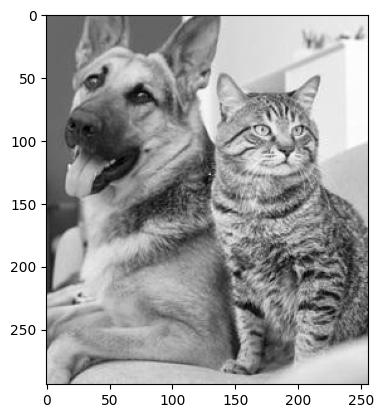

In [7]:
img = cv2.imread('catdog.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(img_gray, cmap='gray')
plt.show()

In [11]:
fg_region = img_gray[40:70, 40:70]  # Foreground region
bg_region = img_gray[5:35, 5:35]

In [12]:
glcm_fg = skft.graycomatrix(fg_region, [1], [0], 256, symmetric=True, normed=True)
glcm_bg = skft.graycomatrix(bg_region, [1], [0], 256, symmetric=True, normed=True)

In [13]:
contrast_fg = skft.graycoprops(glcm_fg, 'contrast')[0, 0]
correlation_fg = skft.graycoprops(glcm_fg, 'correlation')[0, 0]
contrast_bg = skft.graycoprops(glcm_bg, 'contrast')[0, 0]
correlation_bg = skft.graycoprops(glcm_bg, 'correlation')[0, 0]

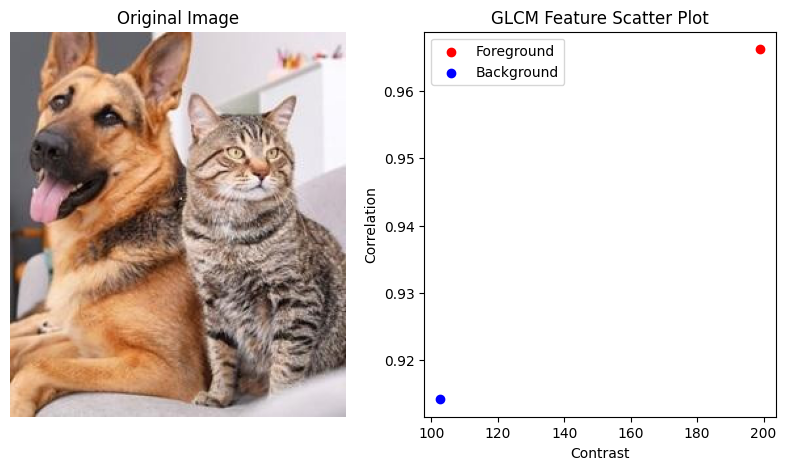

In [14]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.subplot(1, 2, 2)
plt.scatter(contrast_fg, correlation_fg, color='red', label='Foreground')
plt.scatter(contrast_bg, correlation_bg, color='blue', label='Background')
plt.xlabel('Contrast')
plt.ylabel('Correlation')
plt.title('GLCM Feature Scatter Plot')
plt.legend()
plt.show()

### Task 2: LBP Analysis

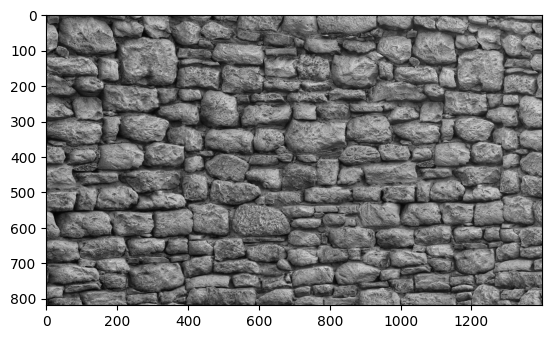

In [15]:
img = cv2.imread('wall.jpg', 0)
plt.imshow(img, cmap='gray')
plt.show()

In [16]:
radius_list = [1, 2, 3]
points_list = [8, 16, 24]

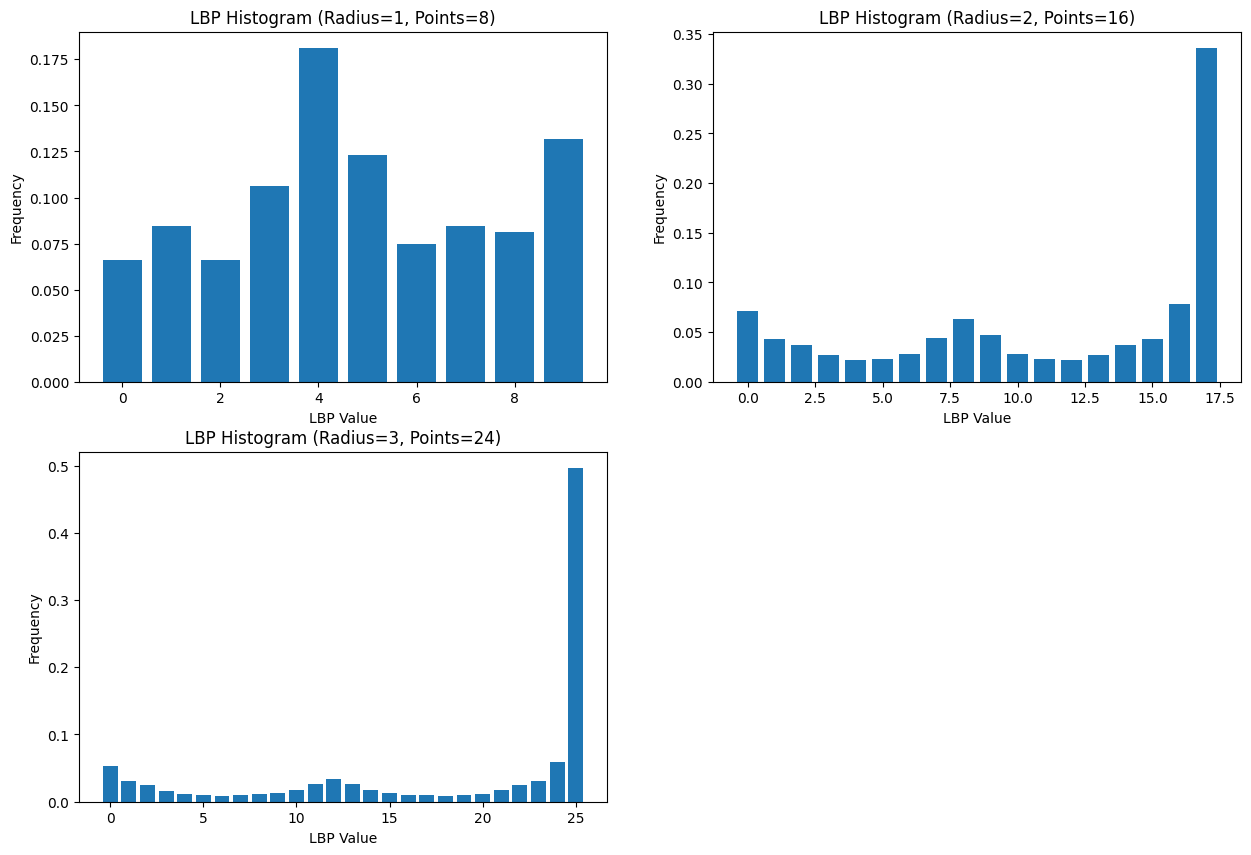

In [18]:
plt.figure(figsize=(15, 10))
for i, (radius, points) in enumerate(zip(radius_list, points_list)):
    # Apply LBP
    lbp = skft.local_binary_pattern(img, points, radius, method='uniform')

    # Calculate histogram
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, points + 3), range=(0, points + 2))
    hist = hist.astype('float')
    hist /= (hist.sum() + 1e-6)

    # Display LBP histogram
    plt.subplot(2, 2, i + 1)
    plt.bar(range(len(hist)), hist)
    plt.title(f'LBP Histogram (Radius={radius}, Points={points})')
    plt.xlabel('LBP Value')
    plt.ylabel('Frequency')

### Task 3: Building vs Forest Classification

In [19]:
!unzip 'buildingVsforest.zip' -d 'buildingVsforest'

Archive:  buildingVsforest.zip
   creating: buildingVsforest/buildingVsforest/
   creating: buildingVsforest/buildingVsforest/data/
   creating: buildingVsforest/buildingVsforest/data/building/
  inflating: buildingVsforest/buildingVsforest/data/building/8121.jpg  
  inflating: buildingVsforest/buildingVsforest/data/building/8129.jpg  
  inflating: buildingVsforest/buildingVsforest/data/building/8131.jpg  
  inflating: buildingVsforest/buildingVsforest/data/building/8132.jpg  
  inflating: buildingVsforest/buildingVsforest/data/building/8139.jpg  
  inflating: buildingVsforest/buildingVsforest/data/building/8151.jpg  
  inflating: buildingVsforest/buildingVsforest/data/building/8159.jpg  
  inflating: buildingVsforest/buildingVsforest/data/building/8171.jpg  
  inflating: buildingVsforest/buildingVsforest/data/building/8179.jpg  
  inflating: buildingVsforest/buildingVsforest/data/building/835.jpg  
  inflating: buildingVsforest/buildingVsforest/data/building/8385.jpg  
  inflating: bu

In [35]:
forest_path = os.path.join('/content/buildingVsforest/buildingVsforest/data', 'forest', '*.jpg')
building_path = os.path.join('/content/buildingVsforest/buildingVsforest/data', 'building', '*.jpg')

In [36]:
forest_images = glob.glob(forest_path)
building_images = glob.glob(building_path)

In [37]:
if len(forest_images) == 0 or len(building_images) == 0:
    print("No images found in the specified folders. Please check the paths and ensure the images are available.")

In [38]:
features = []
labels = []

In [39]:
# Extract GLCM features from forest images
for image_path in forest_images:
    img = cv2.imread(image_path, 0)
    glcm = skft.graycomatrix(img, [1], [0], 256, symmetric=True, normed=True)
    contrast = skft.graycoprops(glcm, 'contrast')[0, 0]
    dissimilarity = skft.graycoprops(glcm, 'dissimilarity')[0, 0]
    homogeneity = skft.graycoprops(glcm, 'homogeneity')[0, 0]
    features.append([contrast, dissimilarity, homogeneity])
    labels.append(0)

In [40]:
# Extract GLCM features from building images
for image_path in building_images:
    img = cv2.imread(image_path, 0)
    glcm = skft.graycomatrix(img, [1], [0], 256, symmetric=True, normed=True)
    contrast = skft.graycoprops(glcm, 'contrast')[0, 0]
    dissimilarity = skft.graycoprops(glcm, 'dissimilarity')[0, 0]
    homogeneity = skft.graycoprops(glcm, 'homogeneity')[0, 0]
    features.append([contrast, dissimilarity, homogeneity])
    labels.append(1)

In [41]:
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.3, random_state=42)

In [42]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [43]:
# Train k-NN classifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [44]:
# Train SVM classifier
svm = SVC(kernel='linear', C=1)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

In [45]:
# Evaluate models
accuracy_knn = accuracy_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

In [46]:
print(f'k-NN Accuracy: {accuracy_knn:.2f}, F1 Score: {f1_knn:.2f}')
print(f'SVM Accuracy: {accuracy_svm:.2f}, F1 Score: {f1_svm:.2f}')

k-NN Accuracy: 0.88, F1 Score: 0.87
SVM Accuracy: 0.88, F1 Score: 0.86


#Inferences

### GLCM Analysis
- The scatter plot of GLCM features shows a clear distinction between the foreground and background regions.
- The foreground region (red point) has higher contrast and correlation values compared to the background region (blue point).
- This indicates that GLCM can effectively capture the texture differences between the cat and dog versus the surrounding background.

### LBP Analysis
- The LBP histograms vary significantly as the radius and the number of sampling points change.
- A smaller radius and fewer sampling points yield a more uniform and less complex histogram.
- Increasing the radius and number of points leads to a histogram with more diversity and peaks, which captures the finer texture details of the wall.
- This highlights the flexibility of LBP in capturing local patterns at different scales and its dependence on the choice of parameters.

### Building vs Forest Classification
- The k-NN classifier achieved an accuracy of 0.88 and an F1 score of 0.87, indicating strong performance in distinguishing between buildings and forests.
- The SVM classifier also achieved an accuracy of 0.88 but a slightly lower F1 score of 0.86.
- Both classifiers performed similarly well, but the k-NN model has a slight edge in F1 score, suggesting it may handle class balance better in this scenario.
- k-NN might be better in this case because it relies on the similarity of feature values to classify new samples, which works well for texture-based features like GLCM. Since buildings and forests have distinct texture patterns, k-NN can leverage the proximity of these patterns effectively, while SVM may struggle slightly due to the complexity of separating textures in a linear way.

